***02 EDA: BENCHMARK ANALYSIS***

In [2]:
# ============================================================
# TBM-X — 02 EDA: BENCHMARK ANALYSIS
# ============================================================
# Amaç:
# Gerçek uçak benchmark verisini istatistiksel ve
# mühendislik açısından incelemek.
#
# Bu aşamada henüz ML yapmıyoruz.
# Önce verinin bize ne söylediğini anlamaya çalışıyoruz..
# ============================================================

print("TBM-X — Benchmark EDA")
print("=" * 60)

TBM-X — Benchmark EDA


**Libraries**

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tbmx.data.quality import iqr_outliers

**Master Dataset**

In [3]:
PROJECT_ROOT = Path.cwd()

MASTER_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "TBM_X_Master_v0_2.csv"
)

df = pd.read_csv(MASTER_PATH)

print(f"Dataset loaded: {df.shape[0]} aircraft")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded: 5 aircraft
Number of columns: 35


**Genearl View**

In [4]:
df

,aircraft_id,manufacturer,variant,family,status,confidence,requirement_flag,MRW_kg,MTOW_kg,MZFW_kg,...,takeoff_power_kW,usable_fuel_L,wing_area_m2,wing_loading_kg_m2,power_to_weight_kW_kg,kg_per_kW,aspect_ratio,empty_weight_fraction,fuel_volume_L_per_MTOW_kg,nominal_cruise_time_h
0,TBM960,Daher,TBM 960,TBM,reported,A,validation_reference,3470.0,3454.000000,2836.0,...,667.401385,1106.000000,18.0,191.888889,0.193226,5.175296,9.144939,0.631152,0.320208,4.803030
1,TBM910,Daher,TBM 910,TBM,reported,B,validation_reference,NaN,3353.861984,NaN,...,633.844891,1101.554829,NaN,NaN,0.188990,5.291298,NaN,0.626048,0.328444,NaN
2,TBM940,Daher,TBM 940,TBM,reported,B,validation_reference,NaN,3354.000000,NaN,...,633.844891,1101.554829,NaN,NaN,0.188982,5.291515,NaN,0.625224,0.328430,NaN
3,PC12NGX,Pilatus,PC-12 NGX,PC12,reported,A,validation_reference,NaN,4740.040267,NaN,...,NaN,1521.735537,NaN,NaN,NaN,NaN,NaN,NaN,0.321039,6.217241
4,M600SLS,Piper,M600/SLS,M600,reported,A,validation_reference,NaN,2721.554220,NaN,...,447.419923,984.207064,NaN,NaN,0.164399,6.082774,NaN,0.608333,0.361634,6.051095


**Numerical Variables**

In [5]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print(f"Number of numerical variables: {len(numeric_columns)}")
print()

for column in numeric_columns:
    print(column)

Number of numerical variables: 28

MRW_kg
MTOW_kg
MZFW_kg
basic_operating_weight_kg
ceiling_m
diameter_m
empty_weight_kg
height_m
landing_distance_50ft_m
length_m
max_cruise_speed_m_s
nominal_power_kW
range_km
rate_of_climb_m_s
rpm
span_m
stall_speed_landing_m_s
takeoff_distance_50ft_m
takeoff_power_kW
usable_fuel_L
wing_area_m2
wing_loading_kg_m2
power_to_weight_kW_kg
kg_per_kW
aspect_ratio
empty_weight_fraction
fuel_volume_L_per_MTOW_kg
nominal_cruise_time_h


**Statistical View**

In [6]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
MRW_kg,1.0,3470.000000,NaN,3470.000000,3470.000000,3470.000000,3470.000000,3470.000000
MTOW_kg,5.0,3524.691294,739.157919,2721.554220,3353.861984,3354.000000,3454.000000,4740.040267
MZFW_kg,1.0,2836.000000,NaN,2836.000000,2836.000000,2836.000000,2836.000000,2836.000000
basic_operating_weight_kg,1.0,3085.788893,NaN,3085.788893,3085.788893,3085.788893,3085.788893,3085.788893
ceiling_m,1.0,9448.800000,NaN,9448.800000,9448.800000,9448.800000,9448.800000,9448.800000
diameter_m,1.0,2.311400,NaN,2.311400,2.311400,2.311400,2.311400,2.311400
empty_weight_kg,4.0,2008.072808,238.108679,1655.612151,1986.653038,2098.339540,2119.759311,2180.000000
height_m,1.0,4.350000,NaN,4.350000,4.350000,4.350000,4.350000,4.350000
landing_distance_50ft_m,1.0,661.416000,NaN,661.416000,661.416000,661.416000,661.416000,661.416000
length_m,1.0,10.740000,NaN,10.740000,10.740000,10.740000,10.740000,10.740000


**Benchmark Aircraft — Maximum Takeoff Weight**

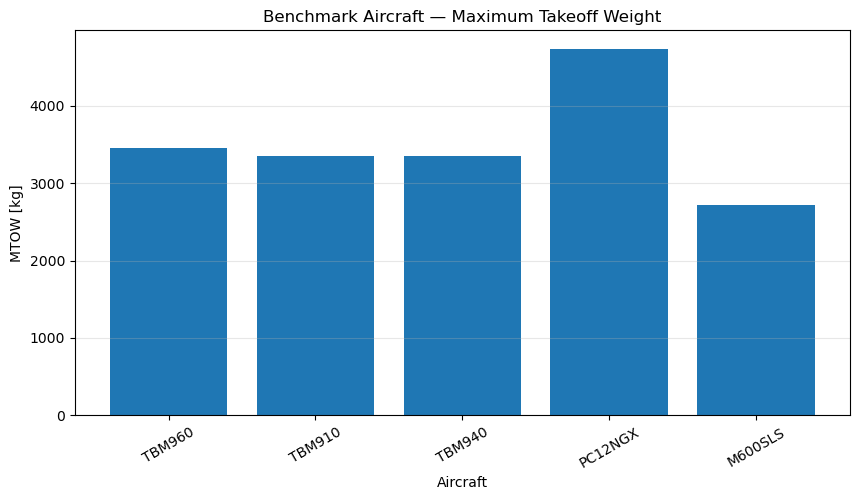

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(
    df["aircraft_id"],
    df["MTOW_kg"]
)

plt.ylabel("MTOW [kg]")
plt.xlabel("Aircraft")
plt.title("Benchmark Aircraft — Maximum Takeoff Weight")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

**Empty Weight Fraction**

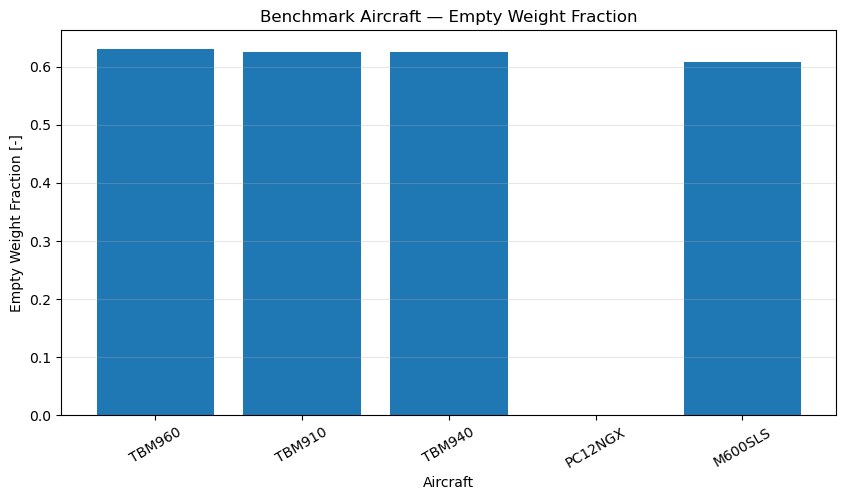

In [8]:
plt.figure(figsize=(10, 5))

plt.bar(
    df["aircraft_id"],
    df["empty_weight_fraction"]
)

plt.ylabel("Empty Weight Fraction [-]")
plt.xlabel("Aircraft")
plt.title("Benchmark Aircraft — Empty Weight Fraction")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

**Range**

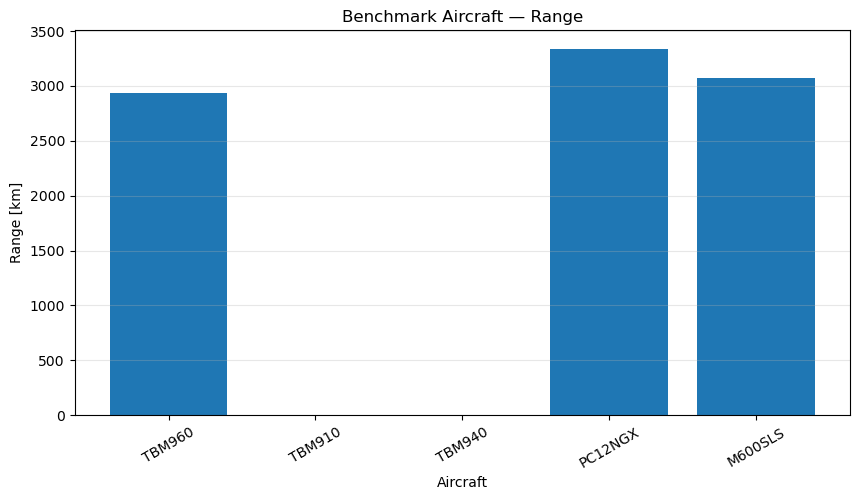

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(
    df["aircraft_id"],
    df["range_km"]
)

plt.ylabel("Range [km]")
plt.xlabel("Aircraft")
plt.title("Benchmark Aircraft — Range")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

**Cruise Speed**

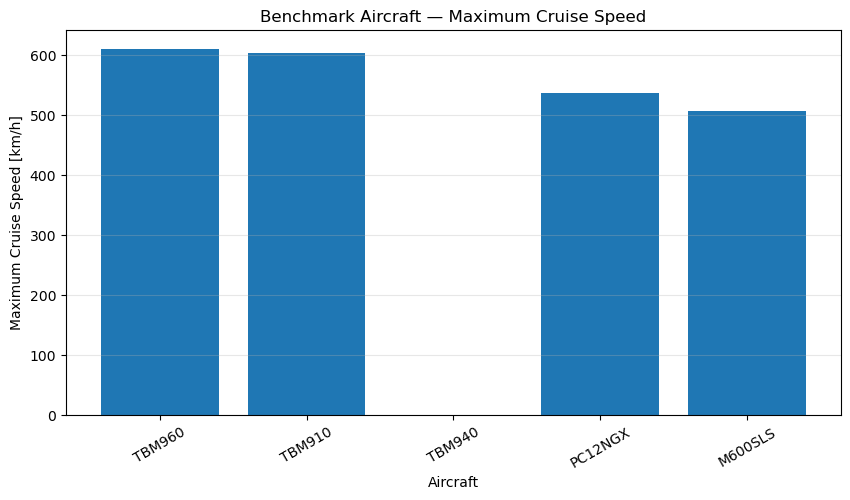

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    df["aircraft_id"],
    df["max_cruise_speed_m_s"] * 3.6
)

plt.ylabel("Maximum Cruise Speed [km/h]")
plt.xlabel("Aircraft")
plt.title("Benchmark Aircraft — Maximum Cruise Speed")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

**Takeoff Power**

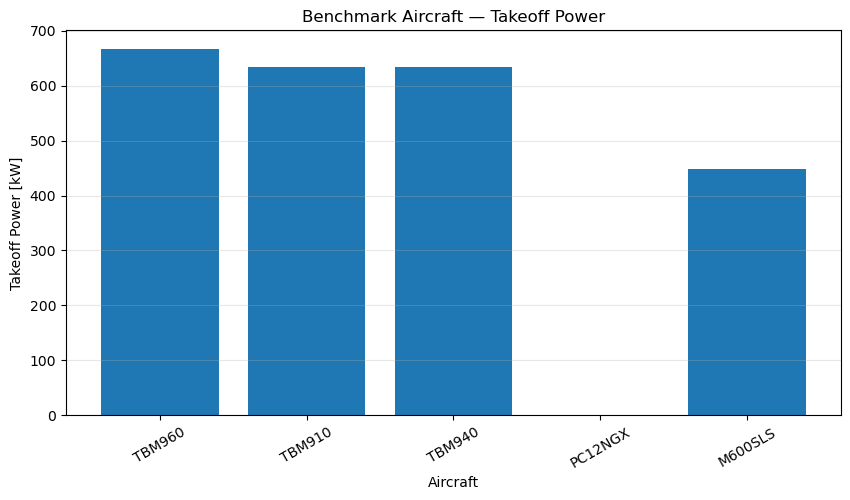

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    df["aircraft_id"],
    df["takeoff_power_kW"]
)

plt.ylabel("Takeoff Power [kW]")
plt.xlabel("Aircraft")
plt.title("Benchmark Aircraft — Takeoff Power")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

**Wing Loading**

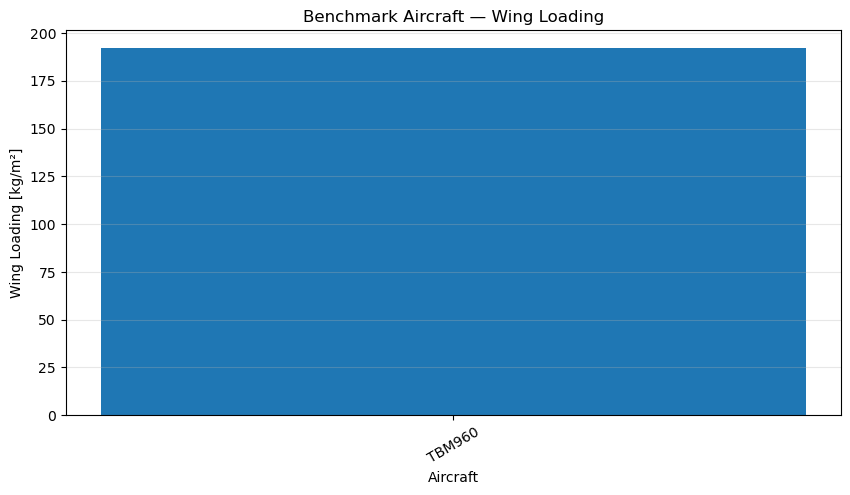

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    df["aircraft_id"],
    df["wing_loading_kg_m2"]
)

plt.ylabel("Wing Loading [kg/m²]")
plt.xlabel("Aircraft")
plt.title("Benchmark Aircraft — Wing Loading")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

**Aspect Ratio**

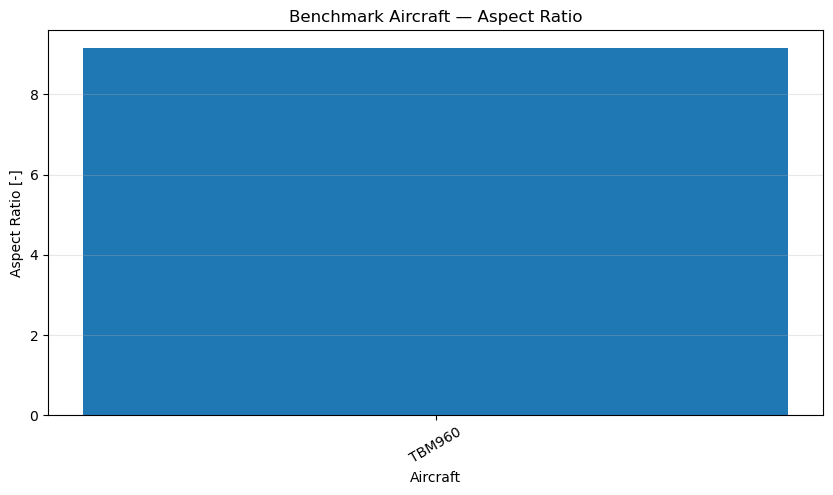

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    df["aircraft_id"],
    df["aspect_ratio"]
)

plt.ylabel("Aspect Ratio [-]")
plt.xlabel("Aircraft")
plt.title("Benchmark Aircraft — Aspect Ratio")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

**Power-to-weight**

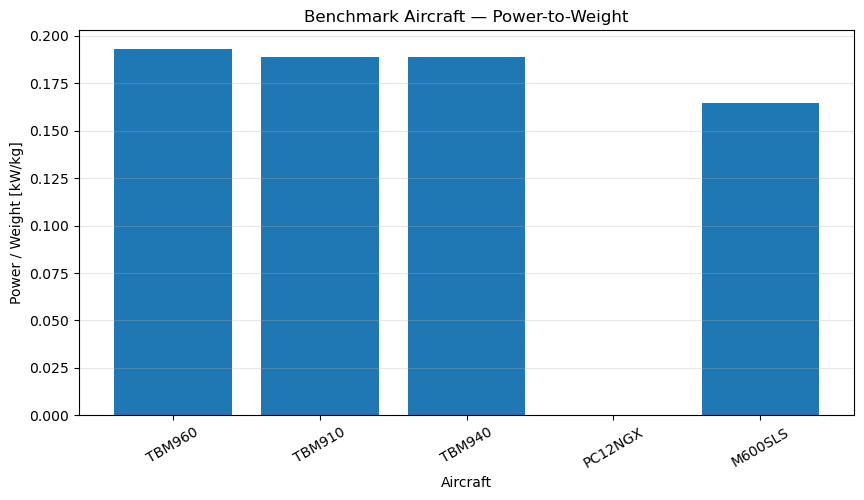

In [14]:
plt.figure(figsize=(10, 5))

plt.bar(
    df["aircraft_id"],
    df["power_to_weight_kW_kg"]
)

plt.ylabel("Power / Weight [kW/kg]")
plt.xlabel("Aircraft")
plt.title("Benchmark Aircraft — Power-to-Weight")

plt.xticks(rotation=30)

plt.grid(axis="y", alpha=0.3)

plt.show()

**MTOW vs Range**

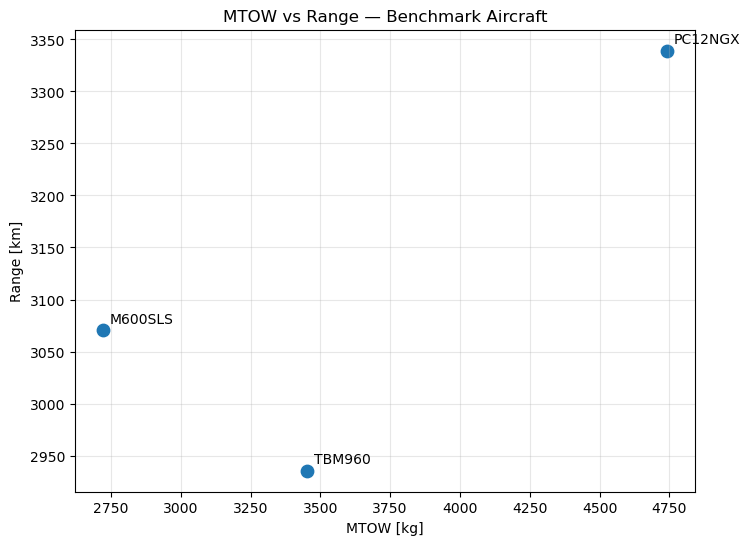

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["MTOW_kg"],
    df["range_km"],
    s=80
)

for _, row in df.dropna(
    subset=["MTOW_kg", "range_km"]
).iterrows():

    plt.annotate(
        row["aircraft_id"],
        (
            row["MTOW_kg"],
            row["range_km"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("MTOW [kg]")
plt.ylabel("Range [km]")
plt.title("MTOW vs Range — Benchmark Aircraft")

plt.grid(alpha=0.3)

plt.show()

**MTOW vs Cruise Speed**

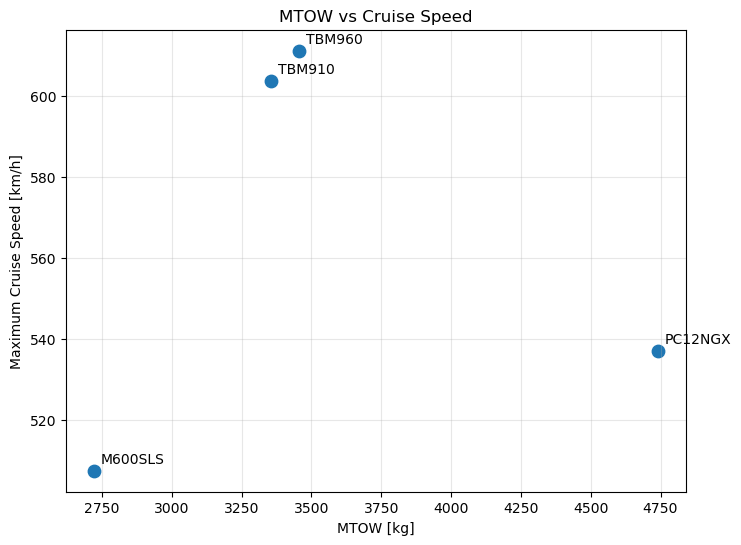

In [16]:
plt.figure(figsize=(8, 6))

speed_kmh = df["max_cruise_speed_m_s"] * 3.6

plt.scatter(
    df["MTOW_kg"],
    speed_kmh,
    s=80
)

for _, row in df.dropna(
    subset=["MTOW_kg", "max_cruise_speed_m_s"]
).iterrows():

    plt.annotate(
        row["aircraft_id"],
        (
            row["MTOW_kg"],
            row["max_cruise_speed_m_s"] * 3.6
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("MTOW [kg]")
plt.ylabel("Maximum Cruise Speed [km/h]")
plt.title("MTOW vs Cruise Speed")

plt.grid(alpha=0.3)

plt.show()

**Range vs Cruise Speed**

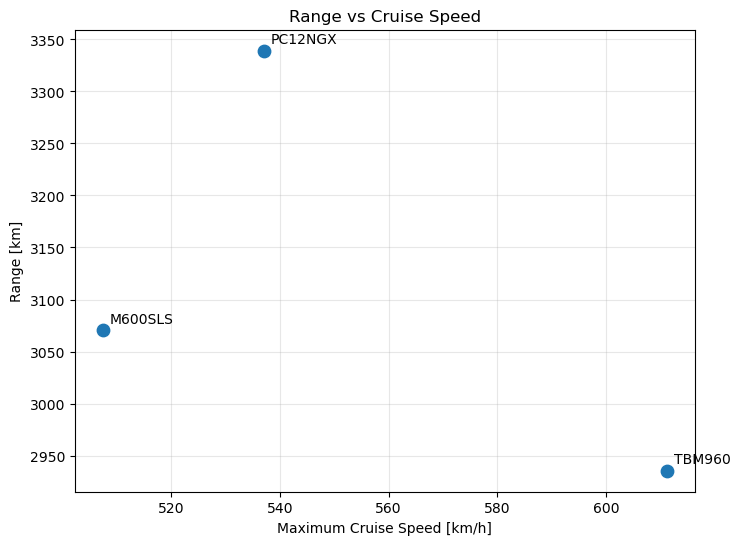

In [17]:
plt.figure(figsize=(8, 6))

valid = df.dropna(
    subset=[
        "range_km",
        "max_cruise_speed_m_s"
    ]
)

plt.scatter(
    valid["max_cruise_speed_m_s"] * 3.6,
    valid["range_km"],
    s=80
)

for _, row in valid.iterrows():

    plt.annotate(
        row["aircraft_id"],
        (
            row["max_cruise_speed_m_s"] * 3.6,
            row["range_km"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Maximum Cruise Speed [km/h]")
plt.ylabel("Range [km]")
plt.title("Range vs Cruise Speed")

plt.grid(alpha=0.3)

plt.show()

**Corelation Matrix**

In [20]:
correlation = df[numeric_columns].corr()

correlation.round(2)

,MRW_kg,MTOW_kg,MZFW_kg,basic_operating_weight_kg,ceiling_m,diameter_m,empty_weight_kg,height_m,landing_distance_50ft_m,length_m,...,takeoff_power_kW,usable_fuel_L,wing_area_m2,wing_loading_kg_m2,power_to_weight_kW_kg,kg_per_kW,aspect_ratio,empty_weight_fraction,fuel_volume_L_per_MTOW_kg,nominal_cruise_time_h
MRW_kg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MTOW_kg,NaN,1.00,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,...,1.00,0.99,NaN,NaN,1.00,-1.00,NaN,0.99,-0.70,0.26
MZFW_kg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basic_operating_weight_kg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ceiling_m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diameter_m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
empty_weight_kg,NaN,1.00,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,...,1.00,0.99,NaN,NaN,1.00,-1.00,NaN,0.99,-1.00,-1.00
height_m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landing_distance_50ft_m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
length_m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


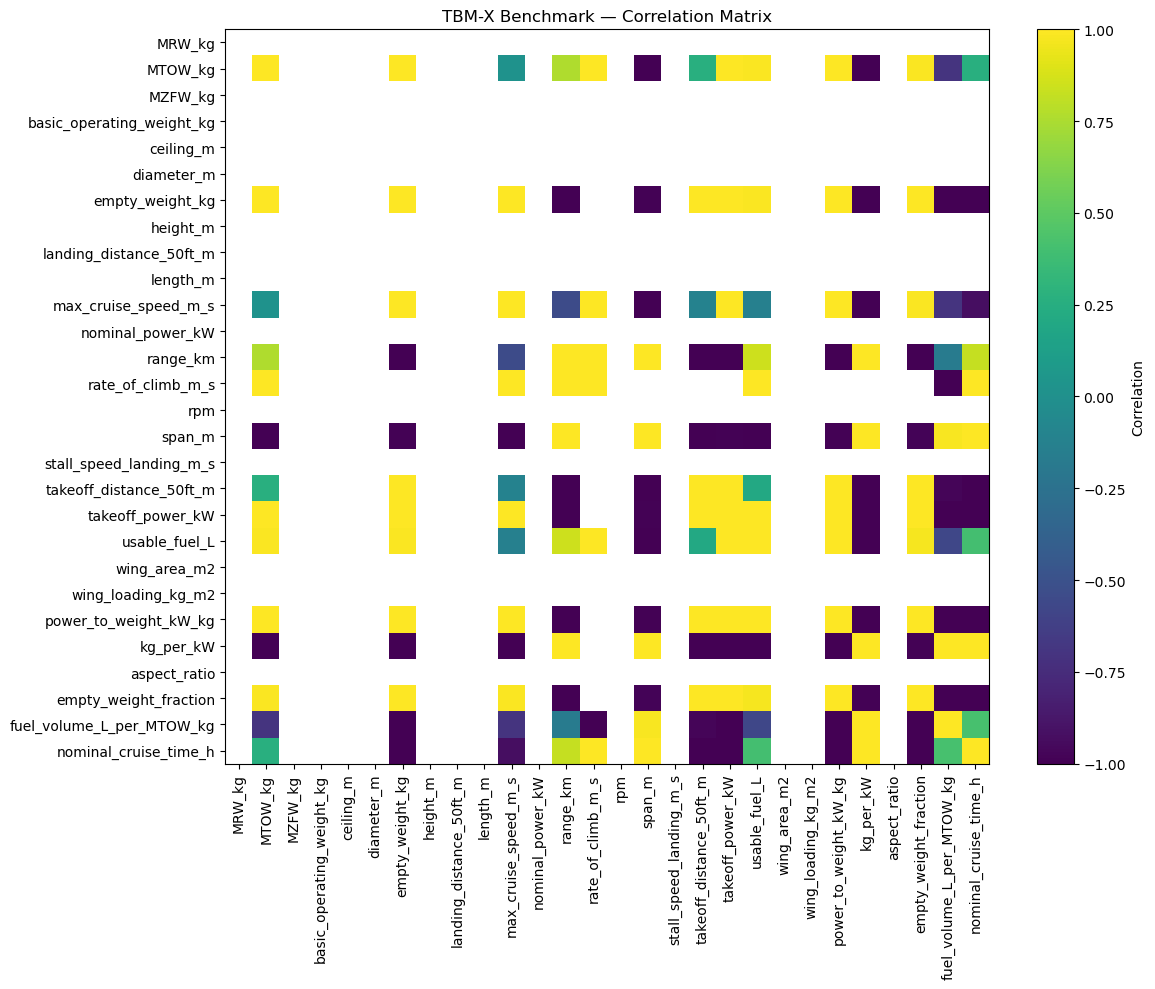

In [21]:
plt.figure(figsize=(12, 10))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.title("TBM-X Benchmark — Correlation Matrix")

plt.tight_layout()

plt.show()

**Outliers**

In [22]:
outliers = iqr_outliers(
    pd.read_csv(
        PROJECT_ROOT
        / "data"
        / "raw"
        / "TBM_X_Benchmark_Dataset_Seed_v0_4.csv"
    )
)

print(f"Potential IQR outlier records: {len(outliers)}")

outliers

Potential IQR outlier records: 2


,row_index,aircraft_id,parameter,value,iqr_low,iqr_high
0,42,M600SLS,takeoff_power,600.0,676.875,971.875
1,4,TBM960,usable_fuel,1106.0,124.500,568.500


**EDA Reports**

In [23]:
print("=" * 70)
print("TBM-X BENCHMARK EDA — SUMMARY")
print("=" * 70)

print(f"Aircraft count       : {df['aircraft_id'].nunique()}")
print(f"Parameter columns    : {len(numeric_columns)}")

print("\nAircraft:")
print(df["aircraft_id"].tolist())

print("\nMTOW range:")
print(
    f"{df['MTOW_kg'].min():.0f} — "
    f"{df['MTOW_kg'].max():.0f} kg"
)

print("\nRange:")
print(
    f"{df['range_km'].min():.0f} — "
    f"{df['range_km'].max():.0f} km"
)

print("\nEDA completed.")

TBM-X BENCHMARK EDA — SUMMARY
Aircraft count       : 5
Parameter columns    : 28

Aircraft:
['TBM960', 'TBM910', 'TBM940', 'PC12NGX', 'M600SLS']

MTOW range:
2722 — 4740 kg

Range:
2935 — 3339 km

EDA completed.
